<a href="https://colab.research.google.com/github/onseventhflow/wine-quality-analysis/blob/main/Wine_Quality_Prediction_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import Libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

 The Wine dataset from Scikit-Learn contains 178 samples with 13 numerical features,
 such as alcohol content, flavonoids, and phenols, representing different chemical
 properties of wines.
 The goal is to classify wines into three types (Class 0, 1, and 2) based on their composition.
 It originates from the UCI Machine Learning Repository and is commonly used for multiclass
 classification tasks.

In [2]:
# Load dataset
data = load_wine()
X, y = data.data, data.target   # Features and target labels

In [3]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Normalize features using Z-score standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Build a neural network model
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')   # 3 output classes (0, 1, 2)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since y is not one-hot encoded
    metrics=['accuracy']
)

In [7]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1,
    validation_data=(X_test, y_test)
)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3975 - loss: 1.2233 - val_accuracy: 0.5000 - val_loss: 1.0335
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6053 - loss: 0.9705 - val_accuracy: 0.7222 - val_loss: 0.8073
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7856 - loss: 0.7666 - val_accuracy: 0.9444 - val_loss: 0.6361
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9230 - loss: 0.6122 - val_accuracy: 0.9444 - val_loss: 0.4916
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9292 - loss: 0.4911 - val_accuracy: 0.9444 - val_loss: 0.3748
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9874 - loss: 0.3294 - val_accuracy: 0.9444 - val_loss: 0.2860
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9795 - loss: 0.2723 - val_accuracy: 0.9444 - val_loss: 0.2221
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9705 - loss: 0.2024 - val_accuracy: 0.9722 - val_loss: 0.1801


In [8]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9421 - loss: 0.1196
Test Accuracy: 94.44%


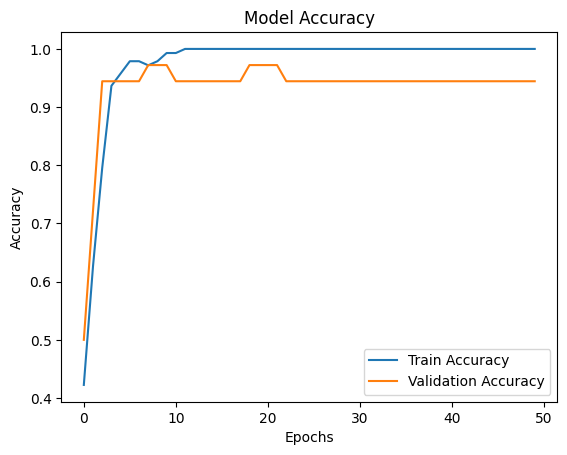

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Class: 0, Actual Class: 0


In [9]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


# Predict a sample
sample_input = np.expand_dims(X_test[0], axis=0)   # Take one test sample
predicted_class = np.argmax(model.predict(sample_input))
print(f"Predicted Class: {predicted_class}, Actual Class: {y_test[0]}")